In [40]:
%matplotlib inline

import os
import sys
from pathlib import Path
import shutil
sys.path.insert(0, '/home/mwalker/git/neoexchange/neoexchange') #point to top of file path
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'neox.settings')
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

import django
django.setup()
from django.conf import settings

import pandas as pd
import numpy as np
from IPython.display import display

from core.models import Body #Body Class
from core.models.sources import StaticSource #static class
from core.models.blocks import Block  #Block class
from core.models.frame import Frame 


os.chdir("/home/mwalker/git/neoexchange/neoexchange") #temp fix for json issue
from core.views import summarize_block_quality
#from core.views import GuideMovie
#from core.plots import generalized_fwhm_plotter, generalized_zeropoint_plotter  #get pngs for fwhm and zp to analyze
from astrometrics.ephem_subs import horizons_ephem
from core.models import Block, StaticSource
from core.management.commands.lightcurve_extraction import Command
from core.views import examine_subtractions
from photometrics.gf_movie import make_gif

from datetime import datetime
from astropy.coordinates import SkyCoord, Angle
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.time import Time
import pandas as pd
import numpy as np
import math
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.dates as mdates
from matplotlib.patches import Circle, Rectangle
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from astropy.table import Table


from photutils import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats  #investigate documentatiom for this
from astropy.stats import sigma_clipped_stats


/tmp/ipykernel_7217/4293055403.py:58: DeprecationWarning: `photutils.DAOStarFinder` is a deprecated alias for `photutils.detection.DAOStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import DAOStarFinder` to silence this warning.
  from photutils import DAOStarFinder


In [3]:
###e-93 files path####

filepath_ecsv = "/home/mwalker/git/didymos_photometry/aper_p_Didymos_712_06_13.ecsv"


table = Table.read(filepath_ecsv, format = "ascii.ecsv")

columns = table.columns

#mask bad columns wit high mag error
mask = (table["magerr"] > 1) | (table["aperture sum"] < 0)
table_g = table[~mask]

RA = table_g["RA"]
dec = table_g["DEC"]
time = table_g['times'].to_datetime()
mags = table_g["mag"]
magerr = table_g["magerr"]
zps = table_g["ZP"]
zps_err = table_g["ZP_sig"]
fwhm = table_g["FWHM"]
alltimes = table["times"].to_datetime()
#airmass

print(table["mag"][:10])


        mag        
-------------------
-4.6674177603641045
  -4.84848416812936
 -4.832755426763708
 -4.566915331083845
 -4.731778093674298
 -4.640344138326219
-3.7428321082749534
  -4.80988471364226
 -3.947525038806601
  -4.35917307765331


In [4]:
fig, ax = plt.subplots(1,1,figsize=(10,5))

ax.errorbar(
    time,
    zps,
    yerr=zps_err,
    fmt='o',
    markersize=4,
    capsize=2
)

ax.set_xlabel("Time")
ax.set_ylabel("Zeropoint (ZP)")
ax.set_title("Zeropoint vs Time (e-93 Didymos)")
plt.grid(True)
ax.invert_yaxis()

# make time axis readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

plt.show()

/tmp/ipykernel_7217/157918621.py:22: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [5]:
###extract airmass ###

airmass = []
for path in table_g["path to frame"]:
    with fits.open(path) as hudl:
        header = hudl[0].header
        airmass.append(header["AIRMASS"])

    

In [6]:
LC_command = Command()


LC_command.plot_timeseries(time,
                           time,
                           mags,
                           magerr,
                           zps,
                           zps_err,
                           fwhm,
                           airmass,
                           colors ="pink",
                           datadir = "/home/mwalker/git/Didymos_data",
                           filename = "tmp_7_12_LC_2",
                           sub_title = "Aperture radius = 15")

/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


In [7]:
filepath_ecsv = "/home/mwalker/git/didymos_photometry/aper_p_Didymos2_712_06_13.ecsv"


table2 = Table.read(filepath_ecsv, format = "ascii.ecsv")

columns = table2.columns

#mask bad columns wit high mag error
mask = (table2["magerr"] > 1) | (table2["aperture sum"] <0)
table_g2 = table2[~mask]

RA2 = table_g2["RA"]
dec2 = table_g2["DEC"]
time2 = table_g2['times'].to_datetime()
mags2 = table_g2["mag"]
magerr2 = table_g2["magerr"]
zps2 = table_g2["ZP"]
zps_err2 = table_g2["ZP_sig"]
fwhm2 = table_g2["FWHM"]
alltimes2 = table2["times"].to_datetime()
#airmass

print(table2["mag"][:10])

###extract airmass ###

airmass2 = []
for path in table_g2["path to frame"]:
    with fits.open(path) as hudl:
        header = hudl[0].header
        airmass2.append(header["AIRMASS"])

    


        mag        
-------------------
  -4.84944758722815
 -4.854825079600032
 -4.558988396209399
  -4.69009436795267
 -4.489947854041469
 -4.700585652892149
 -4.532978414439637
-4.9187943736377795
 -4.395026200250008
  -4.36095544370969


In [8]:
LC_command.plot_timeseries(time2,
                           time2,
                           mags2,
                           magerr2,
                           zps2,
                           zps_err2,
                           fwhm2,
                           airmass2,
                           colors ="pink",
                           datadir = "/home/mwalker/git/Didymos_data",
                           filename = "tmp_7_12_LC_8",
                        sub_title ="Aperture Radius = 8" )

/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  fig.show() #
/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


In [9]:
filepath_ecsv = "/home/mwalker/git/didymos_photometry/aper_p_Didymos5_712_06_13.ecsv"


table5 = Table.read(filepath_ecsv, format = "ascii.ecsv")

columns = table5.columns

#mask bad columns wit high mag error
mask = (table5["magerr"] > 1) | (table5["aperture sum"] < 0)
table_g5 = table5[~mask]

RA5 = table_g5["RA"]
dec5 = table_g5["DEC"]
time5 = table_g5['times'].to_datetime()
mags5 = table_g5["mag"]
magerr5 = table_g5["magerr"]
zps5 = table_g5["ZP"]
zps_err5 = table_g5["ZP_sig"]
fwhm5 = table_g5["FWHM"]
alltimes5 = table5["times"].to_datetime()
#airmass

print(np.min(table_g5["aperture sum"]))

###extract airmass ###

airmass5 = []
for path in table_g5["path to frame"]:
    with fits.open(path) as hudl:
        header = hudl[0].header
        airmass5.append(header["AIRMASS"])

    


52.853736735132095


/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #
/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


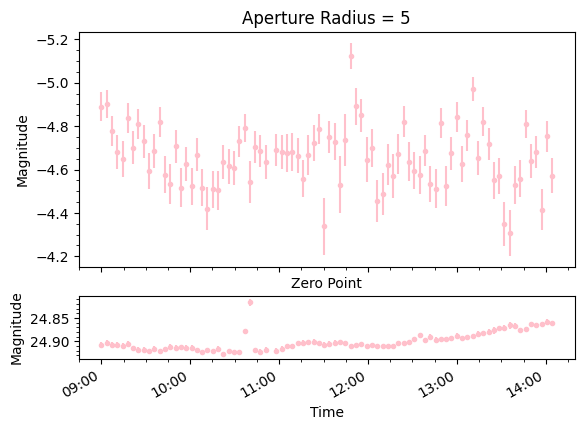

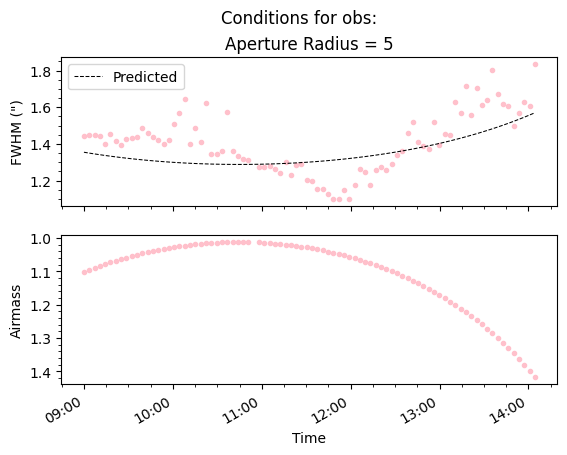

In [41]:
LC_command.plot_timeseries(time5,
                           time5,
                           mags5,
                           magerr5,
                           zps5,
                           zps_err5,
                           fwhm5,
                           airmass5,
                           colors ="pink",
                           datadir = "/home/mwalker/git/Didymos_data",
                           filename = "tmp_7_12_LC_5",
                        sub_title ="Aperture Radius = 5" )

In [11]:
###calculate rough estimate of SNR of 3 aperture sizes

##estimate equation is 1/sqrt(aperture_sum_err)

mean_SNR_ap_13 = np.mean(table_g["aperture sum"] / np.sqrt(table_g["aperture sum err"]))
mean_SNR_ap_8 = np.mean( table_g2["aperture sum"] / np.sqrt(table_g2["aperture sum err"]))
mean_SNR_ap_5 = np.mean( table_g5["aperture sum"] / np.sqrt(table_g5["aperture sum err"]))


print(f"-------------------------\n"
      f"Mean SNR with aperture radius at 13 pixels: {mean_SNR_ap_13}\n"
      f"Mean SNR with aperture radius at 8 pixels: {mean_SNR_ap_8}\n"
      f"Mean SNR with aperture radius at 5 pixels: {mean_SNR_ap_5}\n"
      )



-------------------------
Mean SNR with aperture radius at 13 pixels: 14.058520458756075
Mean SNR with aperture radius at 8 pixels: 22.23071999626583
Mean SNR with aperture radius at 5 pixels: 31.406153713621975



In [12]:
filepath_ecsv = "/home/mwalker/git/didymos_photometry/aper_p_Didymos5snr_712_06_13.ecsv"


table5s = Table.read(filepath_ecsv, format = "ascii.ecsv")

columns = table5s.columns

#mask bad columns wit high mag error
mask = (table5s["magerr"] > 1) | (table5s["aperture sum"] < 0)
table_g5s = table5s[~mask]

RA5s = table_g5s["RA"]
dec5s = table_g5s["DEC"]
time5s = table_g5s['times'].to_datetime()
mags5s = table_g5s["mag"]
magerr5s = table_g5s["magerr"]
zps5s = table_g5s["ZP"]
zps_err5s = table_g5s["ZP_sig"]
fwhm5s = table_g5s["FWHM"]
alltimes5s = table5s["times"].to_datetime()
#airmass

print(table_g5s.colnames)

###extract airmass ###

airmass5s = []
for path in table_g5s["path to frame"]:
    with fits.open(path) as hudl:
        header = hudl[0].header
        airmass5s.append(header["AIRMASS"])

    


['path to frame', 'times', 'filters', 'RA', 'DEC', 'xcenter', 'ycenter', 'aperture sum', 'aperture sum err', 'FWHM', 'ZP', 'ZP_sig', 'mag', 'magerr', 'aperture radius', 'SNR']


/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #
/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


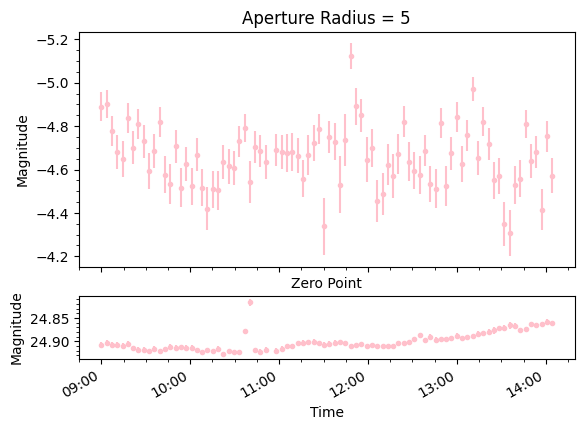

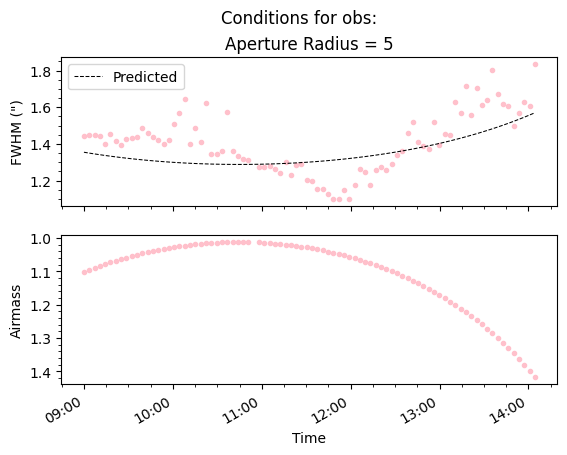

In [ ]:
LC_command.plot_timeseries(time5s,
                           time5s,
                           mags5s,
                           magerr5s,
                           zps5s,
                           zps_err5s,
                           fwhm5s,
                           airmass5s,
                           colors ="pink",
                           datadir = "/home/mwalker/git/Didymos_data",
                           filename = "tmp_7_12_LC_5s",
                        sub_title ="Aperture Radius = 5" )

#change final title: Light Curve Coj 2026-07-12

['path to frame', 'times', 'filters', 'RA', 'DEC', 'xcenter', 'ycenter', 'aperture sum', 'aperture sum err', 'FWHM', 'ZP', 'ZP_sig', 'mag', 'magerr', 'aperture radius', 'SNR']


/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:161: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show() #


Initial FWHM, seeing= 1.442 1.413 arcsec


/home/mwalker/git/neoexchange/neoexchange/core/management/commands/lightcurve_extraction.py:191: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show() #


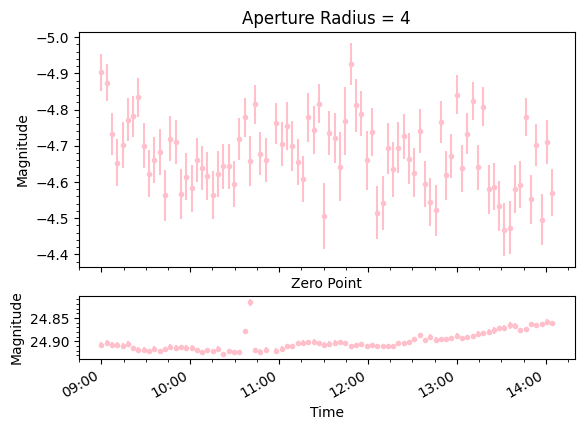

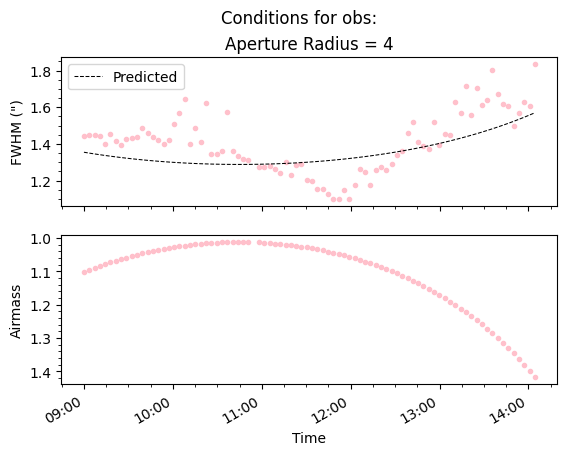

In [81]:
filepath_ecsv_4 = "/home/mwalker/git/didymos_photometry/aper_p_Didymos_712_06_4.ecsv"


table4 = Table.read(filepath_ecsv_4, format = "ascii.ecsv")

columns = table4.columns

#mask bad columns wit high mag error
mask = (table4["magerr"] > 1) | (table4["aperture sum"] < 0)
table_g4s = table4[~mask]

RA4s = table_g4s["RA"]
dec4s = table_g4s["DEC"]
time4s = table_g4s['times'].to_datetime()
mags4s = table_g4s["mag"]
magerr4s = table_g4s["magerr"]
zps4s = table_g4s["ZP"]
zps_err4s = table_g4s["ZP_sig"]
fwhm4s = table_g4s["FWHM"]
alltimes4s = table_g4s["times"].to_datetime()
#airmass

print(table_g4s.colnames)

###extract airmass ###

airmass4s = []
for path in table_g4s["path to frame"]:
    with fits.open(path) as hudl:
        header = hudl[0].header
        airmass4s.append(header["AIRMASS"])

    
 
LC_command.plot_timeseries(time4s,
                           time4s,
                           mags4s,
                           magerr4s,
                           zps4s,
                           zps_err4s,
                           fwhm4s,
                           airmass4s,
                           colors ="pink",
                           datadir = "/home/mwalker/git/Didymos_data",
                           filename = "tmp_7_12_LC_4s",
                        sub_title ="Aperture Radius = 4" )

In [15]:
#mean SNR of radius = 5
print(f"mean SNR with r =5 px is:{np.mean(table_g5s['SNR']):.3f} ")
print(f"mean SNR with r =8 px is:{np.mean(table_g2['SNR']):.3f} ")
print(f"mean SNR with r =13 px is:{np.mean(table_g['SNR']):.3f} ")
print([f'{snr:.3f}' for snr in table_g4s['SNR']])

print(f"mean SNR with r =5 px is:{ np.mean(table_g5s['aperture sum']/np.sqrt(table_g5s['aperture sum err']))}") 




mean SNR with r =5 px is:13.445 
mean SNR with r =8 px is:7.531 
mean SNR with r =13 px is:3.745 
['20.810', '21.103', '18.617', '16.614', '17.154', '18.425', '19.393', '20.105', '17.329', '16.785', '16.870', '17.228', '15.558', '17.353', '17.577', '15.771', '17.008', '16.472', '17.600', '17.865', '16.401', '16.501', '16.985', '17.512', '17.461', '16.766', '18.664', '20.173', '15.561', '20.261', '18.431', '17.815', '19.277', '17.918', '16.681', '15.798', '16.839', '16.928', '16.123', '16.566', '20.048', '12.000', '17.741', '15.693', '11.437', '11.664', '18.560', '14.832', '17.362', '13.370', '16.248', '14.912', '14.676', '15.466', '14.154', '15.327', '17.308', '15.447', '16.045', '17.970', '17.087', '16.644', '15.335', '18.839', '16.116', '17.978', '19.867', '16.692', '18.846', '20.814', '17.518', '20.172', '15.977', '16.787', '15.767', '14.999', '14.967', '16.337', '16.720', '20.286', '16.043', '18.737', '15.539', '17.841', '16.825']
mean SNR with r =5 px is:31.406153713621975


In [16]:
#select file names where mag error > 1 or aperture photometry <= 0:
#select files with any nan values and say what is nan
#

filepath_ecsv_13 = "/home/mwalker/git/didymos_photometry/aper_p_Didymos_712_06_13.ecsv"
filepath_ecsv_5 = "/home/mwalker/git/didymos_photometry/aper_p_Didymos5snr_712_06_13.ecsv"
filepath_ecsv_8 = "/home/mwalker/git/didymos_photometry/aper_p_Didymos2_712_06_13.ecsv"
filepath_ecsv_4 = "/home/mwalker/git/didymos_photometry/aper_p_Didymos_712_06_4.ecsv"

table_13 = Table.read(filepath_ecsv_13, format = "ascii.ecsv")
table_8 = Table.read(filepath_ecsv_8, format = "ascii.ecsv")
table_5 = Table.read(filepath_ecsv_5, format = "ascii.ecsv")
table_4 = Table.read(filepath_ecsv_4, format = "ascii.ecsv")

cols = ["aperture sum", "ZP","mag" ]
nan_mask = np.any([np.isnan(table_13[c])for c in cols], axis = 0) 
mag_mask =  (table_13["aperture sum"] <= 0) #bad aperture
bad_magerr = table_13["magerr"] > 1  #high error in mag

issue_mask = nan_mask | mag_mask | bad_magerr  #files will get flagged for any isue listed       

for i, flagged in enumerate(issue_mask):
    if not flagged:
          continue
    
    if flagged:
         issues = []
         
    if nan_mask[i]:
        bad_cols = [c for c in cols if np.isnan(table_13[c][i])]
        print(f"{table_13['path to frame'][i]} has nan in {bad_cols}")
        issues.append(f"{table_13['path to frame'][i]} has nan in {bad_cols}")

    if bad_magerr[i]:
            issues.append(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]}")
            print(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]}")
    if mag_mask[i]:
         issues.append(f"{table_13['path to frame'][i]} has aperture_sum = {table_13['aperture sum'][i]}")
         print(f"{table_13['path to frame'][i]} has aperture_sum = {table_13['aperture sum'][i]}")

    if mag_mask[i] and bad_magerr[i]:
            issues.append(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]} \n" 
                          f" and has aperture_sum = {table_13['aperture sum'][i]}")
            print(f"{table_13['path to frame'][i]} has magger = {table_13['magerr'][i]} /m" 
                  f"and aperture_sum = {table_13['aperture sum'][i]}")
         


/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0079-e93.fits has nan in ['mag']
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0079-e93.fits has aperture_sum = -7.130750342360114
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0081-e93.fits has nan in ['mag']
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0081-e93.fits has aperture_sum = -6.686866421599019
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0082-e93.fits has nan in ['mag']
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0082-e93.fits has aperture_sum = -3.6214497393618927
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0086-e93.fits has nan in ['mag']
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0086-e93.fits has aperture_sum = -4.066168845016639
/home/mwalker/git/Didymos_data/f06_012_e93/coj2m002-ep07-20260712-0090-e93.fits has nan in ['mag']
/home/mwalker/git/Didymos_data/f

In [17]:
###Look at subtraction quality of e-93's

sub_save_path = "/home/mwalker/git/Didymos_data/subtraction_analysis"
bad_files = [
    "coj2m002-ep07-20260712-0079-e93.fits",
    "coj2m002-ep07-20260712-0081-e93.fits",
    "coj2m002-ep07-20260712-0082-e93.fits",
    "coj2m002-ep07-20260712-0086-e93.fits",
    "coj2m002-ep07-20260712-0090-e93.fits",
    "coj2m002-ep07-20260712-0092-e93.fits",
    "coj2m002-ep07-20260712-0094-e93.fits",
    "coj2m002-ep07-20260712-0098-e93.fits",
    "coj2m002-ep07-20260712-0112-e93.fits",
    "coj2m002-ep07-20260712-0114-e93.fits",
    "coj2m002-ep07-20260712-0116-e93.fits",
    "coj2m002-ep07-20260712-0118-e93.fits",
    "coj2m002-ep07-20260712-0135-e93.fits",
    "coj2m002-ep07-20260712-0136-e93.fits",
    "coj2m002-ep07-20260712-0141-e93.fits",
    "coj2m002-ep07-20260712-0143-e93.fits",
]

bad_blocks = []
for fname in bad_files:
    frame = Frame.objects.filter(filename__contains = fname).first()
    if fname:
        bad_blocks.append(frame.block.id)
        print(f"{fname}, block: {frame.block.id}")
    else:
        print(f"{fname}, NOT FOUND")


coj2m002-ep07-20260712-0079-e93.fits, block: 35906
coj2m002-ep07-20260712-0081-e93.fits, block: 35906
coj2m002-ep07-20260712-0082-e93.fits, block: 35906
coj2m002-ep07-20260712-0086-e93.fits, block: 35906
coj2m002-ep07-20260712-0090-e93.fits, block: 35906
coj2m002-ep07-20260712-0092-e93.fits, block: 35906
coj2m002-ep07-20260712-0094-e93.fits, block: 35906
coj2m002-ep07-20260712-0098-e93.fits, block: 35906
coj2m002-ep07-20260712-0112-e93.fits, block: 35906
coj2m002-ep07-20260712-0114-e93.fits, block: 35906
coj2m002-ep07-20260712-0116-e93.fits, block: 35906
coj2m002-ep07-20260712-0118-e93.fits, block: 35906
coj2m002-ep07-20260712-0135-e93.fits, block: 35906
coj2m002-ep07-20260712-0136-e93.fits, block: 35906
coj2m002-ep07-20260712-0141-e93.fits, block: 35906
coj2m002-ep07-20260712-0143-e93.fits, block: 35906


In [18]:

###use this to make heat map plots of flux values of the fits that we can open with ds9###


obs_block_bad = Block.objects.get(id =bad_blocks[0])
data_storage_filename, badness_storage_filename, bad_filenames, percent_bad_files = examine_subtractions(
                                    obs_block_bad,
                                    sub_save_path,
                                    overwrite = True
 )

try:
    for f in bad_filenames:
        print(f"detected bad frame: {f}")
except:
    IndexError(f"No ifles found")

print(f"percent of bad files: {percent_bad_files}")

detected bad frame: coj2m002-ep07-20260712-0086-e93.fits
detected bad frame: coj2m002-ep07-20260712-0090-e93.fits
percent of bad files: 2.3255813953488373


In [19]:
###access datatable with bad subtraction files

#---i.e colname = bad_subtraction = True

file_path_ecsv_bad = "/home/mwalker/git/Didymos_data/subtraction_analysis/examined_subtractions_table_2026-07-12.ecsv"

table_bad = Table.read(file_path_ecsv_bad, format = "ascii.ecsv")

#select rows with flagged bad tables == True
mask = table_bad["bad_subtraction"] == True

table_bad = table_bad[mask]

for c in table_bad.colnames[:-1]:
    print(f"-------------")
    for val in table_bad[c]:
        try:
            print(f"{c}  {val:.3f} ")
        except (ValueError,TypeError):
            print(val)


#super negative SNR when we get the weird bock distortions -- can use this to recognize them

-------------
mean_up_left  -7.281 
mean_up_left  13.495 
-------------
mean_up_mid  -0.358 
mean_up_mid  0.509 
-------------
mean_up_right  -4.911 
mean_up_right  2.972 
-------------
mean_mid_left  -2.897 
mean_mid_left  -1014.296 
-------------
mean_mid_mid  -2.531 
mean_mid_mid  -2880.352 
-------------
mean_mid_right  -27.027 
mean_mid_right  -445.786 
-------------
mean_low_left  9.881 
mean_low_left  5.263 
-------------
mean_low_mid  -2258.931 
mean_low_mid  38.694 
-------------
mean_low_right  -8.655 
mean_low_right  -7.057 
-------------
std_up_left  33.614 
std_up_left  38.369 
-------------
std_up_mid  33.541 
std_up_mid  35.547 
-------------
std_up_right  34.914 
std_up_right  31.079 
-------------
std_mid_left  34.286 
std_mid_left  422.647 
-------------
std_mid_mid  35.331 
std_mid_mid  104.089 
-------------
std_mid_right  41.745 
std_mid_right  38.154 
-------------
std_low_left  39.383 
std_low_left  33.400 
-------------
std_low_mid  133.535 
std_low_mid  70.841 

In [20]:
###make a gif using the frames--e-93
import glob

frames = []

for f in glob.glob("/home/mwalker/git/Didymos_data/f06_012_e93/*.fits*"):
    if "rms" not in f:
        frames.append(f)
data_path = "/home/mwalker/git/Didymos_data/f06_012_e93"
movie_file = make_gif(frames,
                      title = "Observation: Didymos 202607012",
                      sort=True, init_fr=100, 
                      center=3, 
                      out_path=data_path, 
                      plot_source=True,
                      target_data=None,
                      show_reticle=True, 
                      progress=True)

WARNING [03/Aug/2026 18:41:05] MovieWriter imagemagick unavailable; using Pillow instead.


Creating Gif: Frame 86 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0%| 0.0 sec remaining |


In [21]:
####TASK-####

#Plot SNR and mag scatter by file/point -- Neox aperture phot from lightcurve_extraction
#plot SNR and mag scatter from PhotPiep aperutre photometry
#repeat for DIA aperture photometey ??

#find frames with high scatter, large offsets

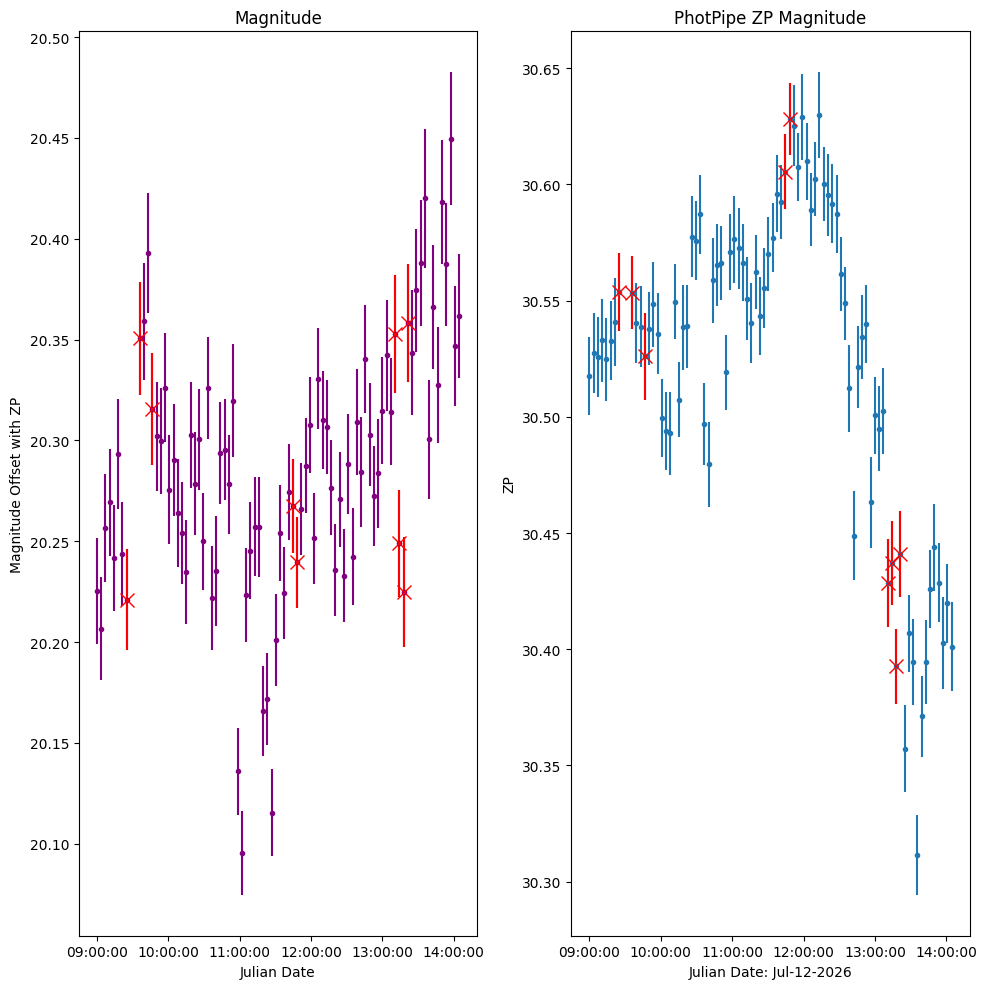

In [80]:
#photPipe analysis ---DART format LC file 7/12/26
import matplotlib.dates as mdates



Phot_path = Path("~/git/Didymos_data/subtraction_analysis/lcogt_coj-PP_ep07_20260712_4253588_65803didymos_photometry.tab").expanduser()
Phot_pipe_table = Table.read(Phot_path, format = "ascii")

Phot_pipe_table.sort('julian_date')


julian_date= Phot_pipe_table['julian_date']
times = Time(julian_date, format='jd').datetime

mag = Phot_pipe_table['mag']
mag_err = Phot_pipe_table['inst_sig']
ZP = Phot_pipe_table['ZP']
ZP_err = Phot_pipe_table['ZP_sig']

flag = Phot_pipe_table["SExtractor_flag"]
bad_flag = flag > 0

fig, ax = plt.subplots(1,2, figsize = (10,10))

# magnitude plot
ax[0].errorbar(times,mag, yerr =mag_err, fmt = '.',color = "purple")
ax[0].set_xlabel("Julian Date")
ax[0].set_ylabel("Magnitude Offset with ZP")
ax[0].set_title("Magnitude")

# flagged points
ax[0].errorbar(
    times[bad_flag],
    mag[bad_flag],
    yerr=mag_err[bad_flag],
    fmt='x',
    color='red',
    markersize=10,
    label="SExtractor flag > 0"
)

#ax[0].invert_yaxis()

# ZP plot
ax[1].errorbar(times,ZP, yerr =ZP_err, fmt = '.')
ax[1].set_xlabel("Julian Date: Jul-12-2026")
ax[1].set_ylabel("ZP")
#ax[1].invert_yaxis()
ax[1].set_title("ZP")

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M:%S')
)

# flagged points
ax[1].errorbar(
    times[bad_flag],
    ZP[bad_flag],
    yerr=ZP_err[bad_flag],
    fmt='x',
    color='red',
    markersize=10,
    label="SExtractor flag > 0"
)

ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.title('PhotPipe ZP Magnitude')
plt.tight_layout()
plt.show()





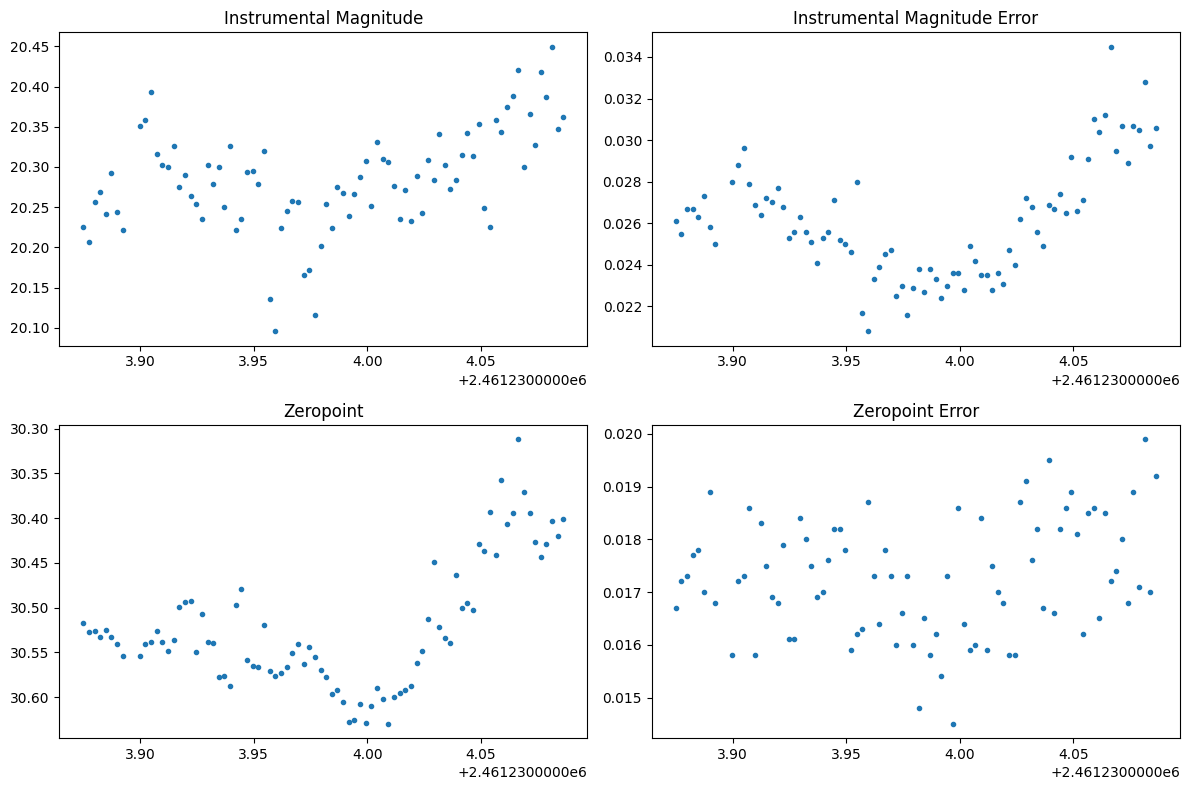

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(julian_date, mag, '.')
ax[0,0].invert_yaxis()
ax[0,0].set_title("Instrumental Magnitude")
ax[0,0].invert_yaxis()

ax[0,1].plot(julian_date, mag_err, '.')
ax[0,1].set_title("Instrumental Magnitude Error")

ax[1,0].plot(julian_date, ZP, '.')
ax[1,0].set_title("Zeropoint")
ax[1,0].invert_yaxis()

ax[1,1].plot(julian_date, ZP_err, '.')
ax[1,1].set_title("Zeropoint Error")

plt.tight_layout()
plt.show()

Maximum mag error: 0.0345
Frame: coj2m002-ep07-20260712-0058-e92.fits


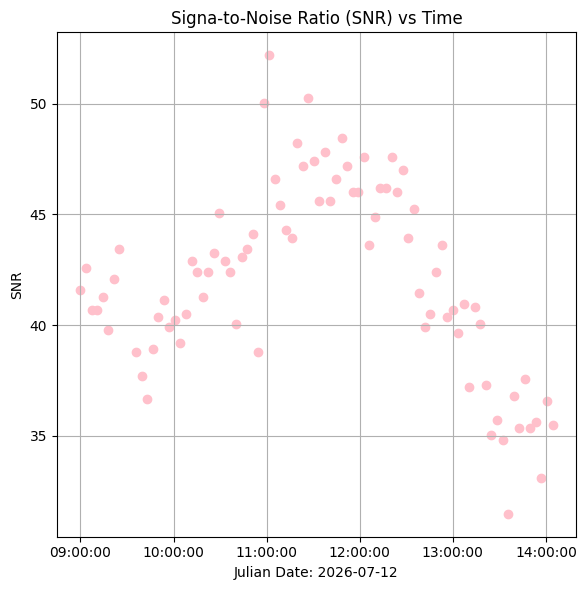

In [82]:
max_mag_error = Phot_pipe_table['inst_sig'].max()
max_err_frame = Phot_pipe_table['file'][max_mag_error.argmax()]

print(f"Maximum mag error: {max_mag_error:.4f}\n"
      f"Frame: {max_err_frame}")


#get flux
flux = 10**(-0.4*(Phot_pipe_table['inst_mag']-Phot_pipe_table['ZP']))
snr = 1.0857 / Phot_pipe_table["inst_sig"]

fig , ax = plt.subplots(figsize=(6,6))

ax.scatter(times,snr, marker = 'o', color = 'pink')
ax.set_xlabel("Julian Date: 2026-07-12")
ax.set_ylabel("SNR")
ax.set_title("Signa-to-Noise Ratio (SNR) vs Time")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.grid()
plt.tight_layout()
plt.show()

In [25]:
###---plot SNR against Airmass----###

# Aquire RA and Dec from field files 

ra_e92 =[]
dec_e92 = []

files_e92 = list(Phot_pipe_table['file'])
frame = Frame.objects.filter(filename__in = files_e92)

for f in frame:
    
    block = f.block
    field_sources = StaticSource.objects.filter(block=block)
    
    for s in field_sources:

        ra_e92.append(s.ra)
        dec_e92.append(s.dec)

In [26]:
### Transform ra, dec ---> alt, az

c = SkyCoord(ra = ra_e92 *u.deg, dec = dec_e92 * u.deg, frame = 'icrs')
t = Time(julian_date, format = 'jd')
location = EarthLocation(
    lat=-31.2733*u.deg,
    lon=149.0719*u.deg,
    height=1165*u.m
)
c_alt_az = c.transform_to(AltAz(obstime = t, location = location))

airmass = c_alt_az.secz

In [27]:
# print(c_alt_az.alt)
# print(c_alt_az.secz)
print(c_alt_az.alt)
print(airmass.min(), airmass.max())

[64d57m40.3448533s 65d42m11.88209407s 66d26m32.04208598s
 67d10m35.17331918s 67d54m24.73423187s 68d37m57.18497841s
 69d21m12.87609362s 70d04m08.02920287s 72d10m26.23093066s
 72d51m32.36419307s 73d32m04.98307402s 74d11m53.86657002s
 74d50m56.76094537s 75d29m06.29202587s 76d06m17.90657325s
 76d42m19.65417477s 77d17m04.1425903s 77d50m19.92466997s
 78d21m51.09571743s 78d51m25.785187s 79d18m46.88360353s 79d43m35.89250102s
 80d05m34.67766284s 80d24m23.4942808s 80d39m43.40314113s
 80d51m16.05208029s 80d58m47.36942255s 81d02m07.1091063s 81d01m10.7735387s
 80d55m59.60434625s 80d46m41.05746461s 80d33m26.51579207s
 80d16m31.34731149s 79d56m16.42924299s 79d33m00.52940101s
 79d07m03.10207513s 78d38m41.8067981s 78d08m14.23464959s
 77d35m56.33283172s 77d02m00.5757309s 76d26m42.14299235s
 75d50m08.01803034s 75d12m30.30486575s 74d33m55.8531831s
 73d54m31.84655279s 73d14m23.86644531s 72d33m37.25605453s
 71d52m16.57959885s 71d10m25.41018218s 70d28m07.52077183s
 69d45m25.65001893s 69d02m22.36770648s 68d18

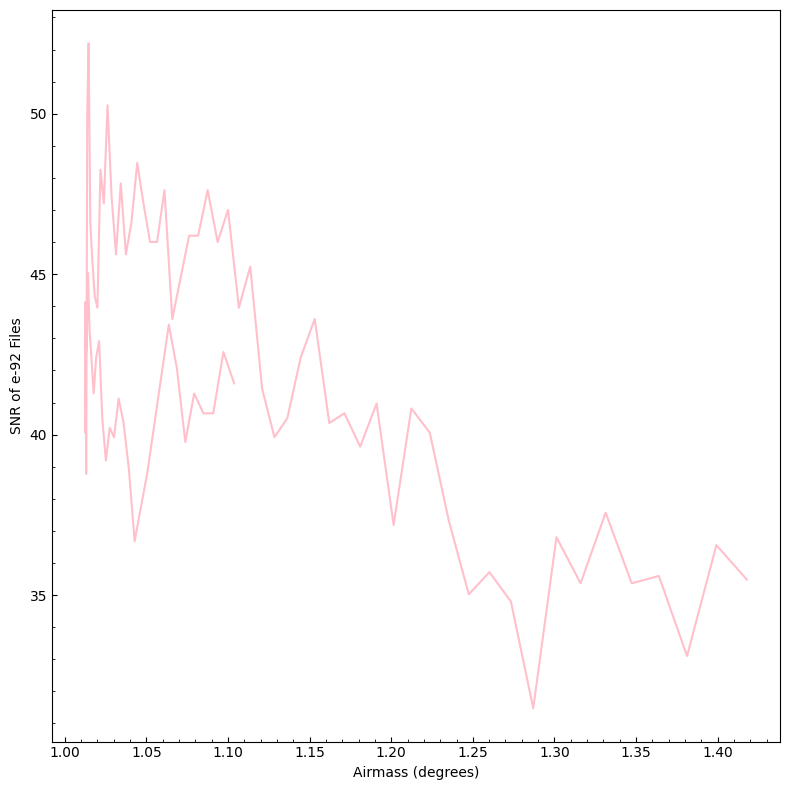

In [47]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
z = np.degrees(np.arccos(1/airmass))
ax.plot(airmass,snr,color = "pink")
ax.set_xlabel("Airmass (degrees)")
ax.set_ylabel("SNR of e-92 Files")

# major ticks
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.tick_params(
    axis='both',
    which='both',
    direction='in',
    bottom=True,
    left=True
)

plt.tight_layout()
plt.show()


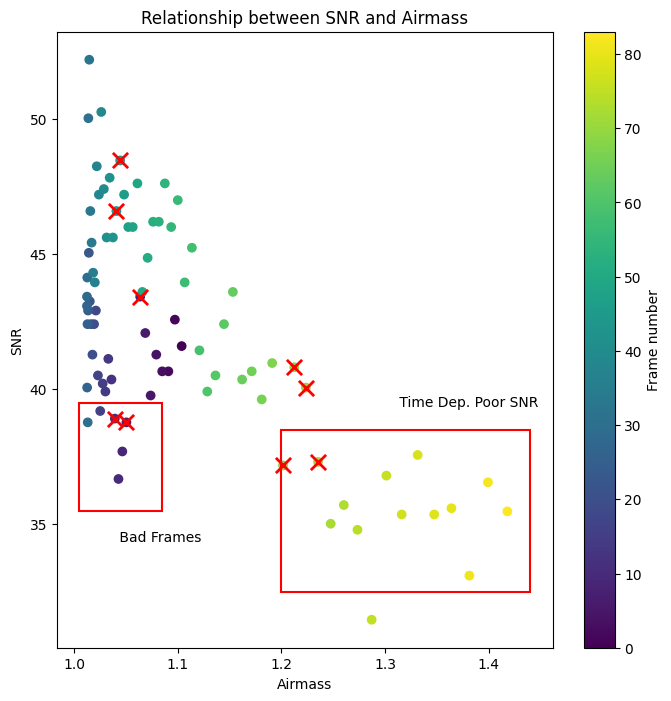

In [48]:
fig, ax = plt.subplots(figsize=(8,8))

flag = Phot_pipe_table["SExtractor_flag"]
bad_flag = flag > 0



sc = ax.scatter(
    airmass,
    snr,
    c=np.arange(len(snr)),
    cmap="viridis"
)

# highlight SExtractor flagged frames
ax.scatter(
    airmass[bad_flag],
    snr[bad_flag],
    marker="x",
    s=120,
    linewidths=2,
    color="red",
    label="SExtractor flag > 0"
)
#highlight certain areas
box_bad = Rectangle(
    (1.03 -0.05/2, 37 - 3/2), 
     0.08,   #width in x
     4, #height in y
     fill = False,
     linewidth = 1.5,
     color = "red" 
)

box_time = Rectangle(
    (1.29 - 0.18/2, 35 -5/2), 
     0.24,   #width in x
     6, #height in y
     fill = False,
     linewidth = 1.5, 
     color = "red"
)

ax.add_patch(box_bad)
ax.add_patch(box_time)

 # label point
ax.annotate(
    f" Bad Frames",
    (1.03, 34),
    xytext=(7, 7),
    textcoords="offset points"
)

 # label point
ax.annotate(
    f" Time Dep. Poor SNR",
    (1.30, 39),
    xytext=(7, 7),
    textcoords="offset points"
)


ax.set_xlabel("Airmass")
ax.set_ylabel("SNR")
ax.set_title("Relationship between SNR and Airmass")
plt.colorbar(sc, label="Frame number")
plt.show()

In [30]:
#frames with snr < 38 ---bad frames --will also further divide by airmass x-axis for boxes

mask = snr <38

for i in np.where(mask)[0]:
    print(f"---------------------------------------")
    print(f"{Phot_pipe_table['file'][i]}")
    print(f"Frame {i}: Airmass={airmass[i]:.3f}, SNR={snr[i]:.2f}")



---------------------------------------
coj2m002-ep07-20260712-0069-e92.fits
Frame 9: Airmass=1.046, SNR=37.70
---------------------------------------
coj2m002-ep07-20260712-0070-e92.fits
Frame 10: Airmass=1.043, SNR=36.68
---------------------------------------
coj2m002-ep07-20260712-0128-e92.fits
Frame 68: Airmass=1.201, SNR=37.18
---------------------------------------
coj2m002-ep07-20260712-0131-e92.fits
Frame 71: Airmass=1.235, SNR=37.31
---------------------------------------
coj2m002-ep07-20260712-0132-e92.fits
Frame 72: Airmass=1.248, SNR=35.02
---------------------------------------
coj2m002-ep07-20260712-0133-e92.fits
Frame 73: Airmass=1.260, SNR=35.71
---------------------------------------
coj2m002-ep07-20260712-0134-e92.fits
Frame 74: Airmass=1.273, SNR=34.80
---------------------------------------
coj2m002-ep07-20260712-0135-e92.fits
Frame 75: Airmass=1.287, SNR=31.47
---------------------------------------
coj2m002-ep07-20260712-0136-e92.fits
Frame 76: Airmass=1.301, SNR

In [31]:
#-----cross check with midpoint values----#


frames_test = (Frame.objects.filter(
        block_id=35906,
        frametype=Frame.NEOX_RED_FRAMETYPE,
        filter='rp'
    ).order_by('midpoint')
    .values(
        'filename',
        'midpoint',
        'zeropoint',
        'zeropoint_err',
        'exptime'
    )
)

for f in frames_test:
    print(
        f"{f['midpoint']}  "
        f"ZP={f['zeropoint']:.3f} ± {f['zeropoint_err']:.3f}  "
        f"{f['filename']}"
    )


2026-07-12 08:59:58.809000  ZP=24.789 ± 0.011  coj2m002-ep07-20260712-0058-e92.fits
2026-07-12 09:03:33.919000  ZP=24.795 ± 0.011  coj2m002-ep07-20260712-0059-e92.fits
2026-07-12 09:07:09.063000  ZP=24.797 ± 0.010  coj2m002-ep07-20260712-0060-e92.fits
2026-07-12 09:10:43.888000  ZP=24.801 ± 0.011  coj2m002-ep07-20260712-0061-e92.fits
2026-07-12 09:14:18.787000  ZP=24.794 ± 0.010  coj2m002-ep07-20260712-0062-e92.fits
2026-07-12 09:17:53.615000  ZP=24.801 ± 0.010  coj2m002-ep07-20260712-0063-e92.fits
2026-07-12 09:21:28.540000  ZP=24.808 ± 0.010  coj2m002-ep07-20260712-0064-e92.fits
2026-07-12 09:25:03.442000  ZP=24.814 ± 0.010  coj2m002-ep07-20260712-0065-e92.fits
2026-07-12 09:28:38.269000  ZP=24.809 ± 0.011  coj2m002-ep07-20260712-0066-e92.fits
2026-07-12 09:32:13.113000  ZP=24.813 ± 0.011  coj2m002-ep07-20260712-0067-e92.fits
2026-07-12 09:35:48.040000  ZP=24.814 ± 0.010  coj2m002-ep07-20260712-0068-e92.fits
2026-07-12 09:39:22.853000  ZP=24.808 ± 0.011  coj2m002-ep07-20260712-0069-e

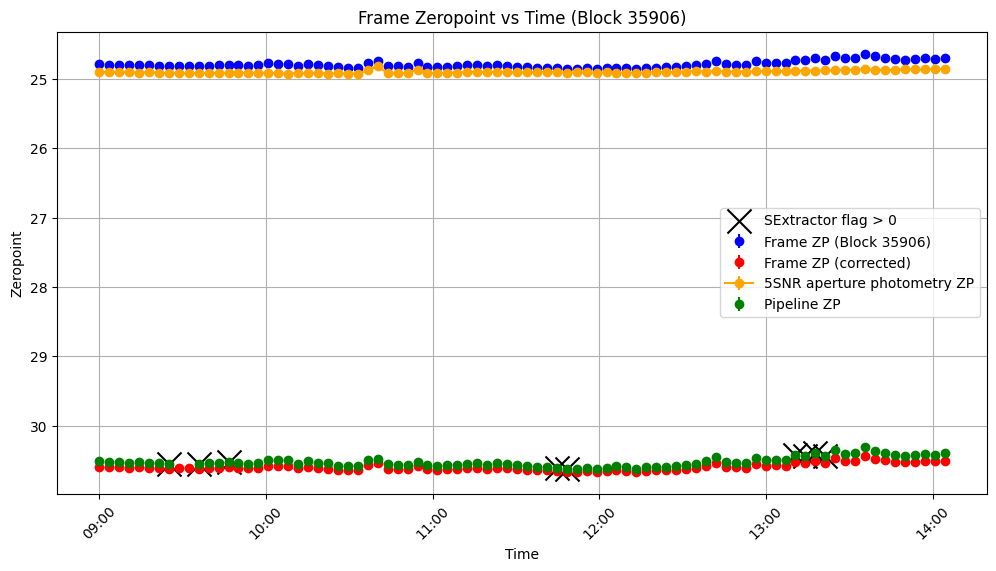

In [78]:

#--------------------------------------------------------
#e-93 5 + SNR TABLE
#--------------------------------------------------------
table_5 = Table.read(filepath_ecsv_5, format="ascii.ecsv")


# Pipeline ZP time series
times_5 = Time(
    table_5["times"],
    format="jd"
).datetime

ZP_5 = table_5["ZP"]
ZP_err_5 = table_5["ZP_sig"]

# --------------------------------------------------
# Get frame information from database
# --------------------------------------------------
frames_test = (
    Frame.objects.filter(
        block_id=35906,
        frametype=Frame.NEOX_RED_FRAMETYPE,
        filter='rp'
    )
    .order_by('midpoint')
    .values(
        'filename',
        'midpoint',
        'zeropoint',
        'zeropoint_err',
        'exptime'
    )
)

# Convert Django queryset -> Astropy table
db_t = Table(rows=list(frames_test))

# Correct ZP for exposure time
zp_corrected = db_t["zeropoint"] + 2.5 * np.log10(db_t["exptime"])

# Convert database times
times = Time(db_t["midpoint"]).datetime


# --------------------------------------------------
# Read photometry pipeline table
# --------------------------------------------------
Phot_path = Path(
    "~/git/Didymos_data/subtraction_analysis/"
    "lcogt_coj-PP_ep07_20260712_4253588_65803didymos_photometry.tab"
).expanduser()

Phot_pipe_table = Table.read(
    Phot_path,
    format="ascii"
)

Phot_pipe_table.sort('julian_date')

# Pipeline times
julian_date = Phot_pipe_table["julian_date"]
phot_times = Time(julian_date, format="jd").datetime

# Pipeline ZP
ZP = Phot_pipe_table["ZP"]
ZP_err = Phot_pipe_table["ZP_sig"]

# SExtractor flags
flag = Phot_pipe_table["SExtractor_flag"]
bad_flag = flag > 0


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))


# Raw Frame ZP
ax.errorbar(
    times,
    db_t["zeropoint"],
    yerr=db_t["zeropoint_err"],
    fmt='o',
    label="Frame ZP (Block 35906)",
    color = "blue"
)


# Exposure-corrected Frame ZP
ax.errorbar(
    times,
    zp_corrected,
    yerr=db_t["zeropoint_err"],
    fmt='o',
    label="Frame ZP (corrected)",
    color = "red"
)
#add e-93s
ax.errorbar(
    times_5,
    ZP_5,
    yerr=ZP_err_5,
    fmt='o-',
    color='orange',
    label="5SNR aperture photometry ZP"
)

# Pipeline ZP (orange)
ax.errorbar(
    phot_times,
    ZP,
    yerr=ZP_err,
    fmt='o',
    color='green',
    label="Pipeline ZP"
)


# Mark flagged pipeline files
ax.scatter(
    phot_times[bad_flag],
    ZP[bad_flag],
    marker='x',
    s=300,
    color='black',
    label="SExtractor flag > 0"
)


# Formatting
ax.set_xlabel("Time")
ax.set_ylabel("Zeropoint")
ax.set_title("Frame Zeropoint vs Time (Block 35906)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)

ax.legend()
ax.grid(True)
ax.invert_yaxis()
plt.show()

In [58]:
db_t['exptime'][5:10]

210.0
210.0
210.0
210.0
210.0


In [34]:
###--- SEXTRACTOR FLAGGING ---###
flag = Phot_pipe_table['SExtractor_flag']


# 3 --ap phot biased by neighboring sources + object is deblended
#2 --deblended

unique, counts, index = np.unique(flag, return_counts=True, return_index=True)

for u, c, i in zip(unique,counts,index):
    print(f"---------------------------")
    print(f"index{i}: flag{u} {c} frames")

mask_flag = flag > 0

phot_pipe_t_flag = Phot_pipe_table[mask_flag]

for row in phot_pipe_t_flag:
    print(f"--------------------------")
    print(f"{row['file']}, {row['SExtractor_flag']}")





---------------------------
index75: flag0 0 frames
---------------------------
index3: flag2 11 frames
---------------------------
index6: flag3 7 frames
--------------------------
coj2m002-ep07-20260712-0065-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0068-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0071-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0104-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0105-e92.fits, 2
--------------------------
coj2m002-ep07-20260712-0128-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0129-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0130-e92.fits, 3
--------------------------
coj2m002-ep07-20260712-0131-e92.fits, 3


Changed badness Threshold for `examine_subtraction`

In [35]:

###use this to make heat map plots of flux values of the fits that we can open with ds9###


obs_block_bad = Block.objects.get(id =bad_blocks[0])
data_storage_filename_500, badness_storage_filename_500, bad_filenames_500, percent_bad_files_500 = examine_subtractions(
                                    obs_block_bad,
                                    sub_save_path,
                                    overwrite = True,
                                    badness_threshold = 400
 )

try:
    for f in bad_filenames_500:
        print(f"detected bad frame: {f}")
except:
    IndexError(f"No ifles found")

print(f"percent of bad files: {percent_bad_files_500}")

detected bad frame: coj2m002-ep07-20260712-0058-e93.fits
detected bad frame: coj2m002-ep07-20260712-0059-e93.fits
detected bad frame: coj2m002-ep07-20260712-0060-e93.fits
detected bad frame: coj2m002-ep07-20260712-0061-e93.fits
detected bad frame: coj2m002-ep07-20260712-0063-e93.fits
detected bad frame: coj2m002-ep07-20260712-0064-e93.fits
detected bad frame: coj2m002-ep07-20260712-0071-e93.fits
detected bad frame: coj2m002-ep07-20260712-0075-e93.fits
detected bad frame: coj2m002-ep07-20260712-0076-e93.fits
detected bad frame: coj2m002-ep07-20260712-0079-e93.fits
detected bad frame: coj2m002-ep07-20260712-0080-e93.fits
detected bad frame: coj2m002-ep07-20260712-0086-e93.fits
detected bad frame: coj2m002-ep07-20260712-0089-e93.fits
detected bad frame: coj2m002-ep07-20260712-0090-e93.fits
detected bad frame: coj2m002-ep07-20260712-0128-e93.fits
detected bad frame: coj2m002-ep07-20260712-0130-e93.fits
detected bad frame: coj2m002-ep07-20260712-0133-e93.fits
detected bad frame: coj2m002-ep

In [93]:
def bad_sub_highlighter(e93_bad_file_loc, base_dir_e93):
    """
    Objective: Locate poorly subtracted files, get the sum counts of the 9 boxes, 
    create rectangles of negative boxes that are 3x more negative thant the median box.

    Inputs:
    e93_file_loc (string): Has file path Table generated from `examine_subtractions` method
    base_dir_e93 (string): where ALL e93's are located

    Returns:
    Rectangle (matplotlib.patches.Rectangle): as in ax.add_patch(rect)

    """
    
    examine_subtractions_table = Table.read(e93_bad_file_loc, format = "ascii.ecsv")

    #Retreve  bad files
    bad_filenames =  examine_subtractions_table["filename"][
        examine_subtractions_table["bad_subtraction"] == True]
    
    bad_table = examine_subtractions_table[examine_subtractions_table["bad_subtraction"] == True]
    
    files = [os.path.join(base_dir_e93,f) for f in bad_filenames]

    #For each file, apply column mask for mean < 0 & std mask > 5
    mean_columns = [c for c in examine_subtractions_table.columns if c.strip(" ").split("_")[0] == "mean"]
    std_columns = [c for c in examine_subtractions_table.columns if c.strip(" ").split("_")[0] == "std"]
   
    #select boxes that are bad
    # only use already-selected bad subtraction files
    # store results
    bad_boxes_data = []

    for row in bad_table:

        for mean_col, std_col in zip(mean_columns, std_columns):

            if (row[mean_col] < -100) and (row[std_col] > 34.5): #VERY neg + STD
                fragment = mean_col.split("_")[1:3]
                x_col = f"x_cen_{fragment[0]}_{fragment[1]}"
                y_col = f"y_cen_{fragment[0]}_{fragment[1]}"
                bad_boxes_data.append(
                    (
                        row["filename"],
                        mean_col.replace("mean_", ""),
                        row[mean_col],
                        row[std_col],
                        row[x_col],
                        row[y_col]
                    )
                )

    # create Astropy table
    bad_boxes_table = Table(
        rows=bad_boxes_data,
        names=["filename", "box", "mean", "std", "xcen", "ycen"]
    )
    
    # Plot the xcen, yceb and a box around it 

    n = len(files)

    #make roughly square grid
    ncols = math.ceil(np.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
         nrows,
         ncols,
         figsize=(4.5*ncols, 4.5*nrows),
         squeeze=False
     )
    fig.suptitle(
        "Files with Badness Threshold > 400 and Pixel Value < -100",
        fontsize = 28,
        y = 0.95 ) #title above axis)

    axes = axes.flatten()

    for ax, filename in zip(axes, files):

        with fits.open(filename) as hdul:
            data = hdul[0].data

            #get length and width ofa box 1/9 of image
            y , x = data.shape
            xwidth = x / 3
            ywidth = y /3
         # optional: improve contrast
        vmin, vmax = np.nanpercentile(data, [1, 99])

        im = ax.imshow(
             data,
             origin="lower",
             cmap="Greys",
             vmin=vmin,
             vmax=vmax
         )
        
        rows = bad_boxes_table[bad_boxes_table["filename"] == filename.split('/')[-1]] #select all rows associaed with fits
        for row in rows:
            xcen = row["xcen"]
            ycen = row["ycen"]
        
            #draw rectangle
            rect = Rectangle((xcen - xwidth/2, ycen - ywidth/2),
                             xwidth,
                             ywidth,
                             fill = False,
                             edgecolor = "red",
                             linewidth = 2
                             )
            ax.add_patch(rect)
            file_name = filename.split("/")[-1]

        ax.set_title(f"Frame: {file_name.split('-')[3]}", fontsize=12)

     # remove unused panels
    for ax in axes[len(files):]:
         ax.axis("off")

     # colorbar on far right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    fig.colorbar(
         im,
         cax=cbar_ax,
         label="Flux"
     )

    #plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

    return bad_boxes_table



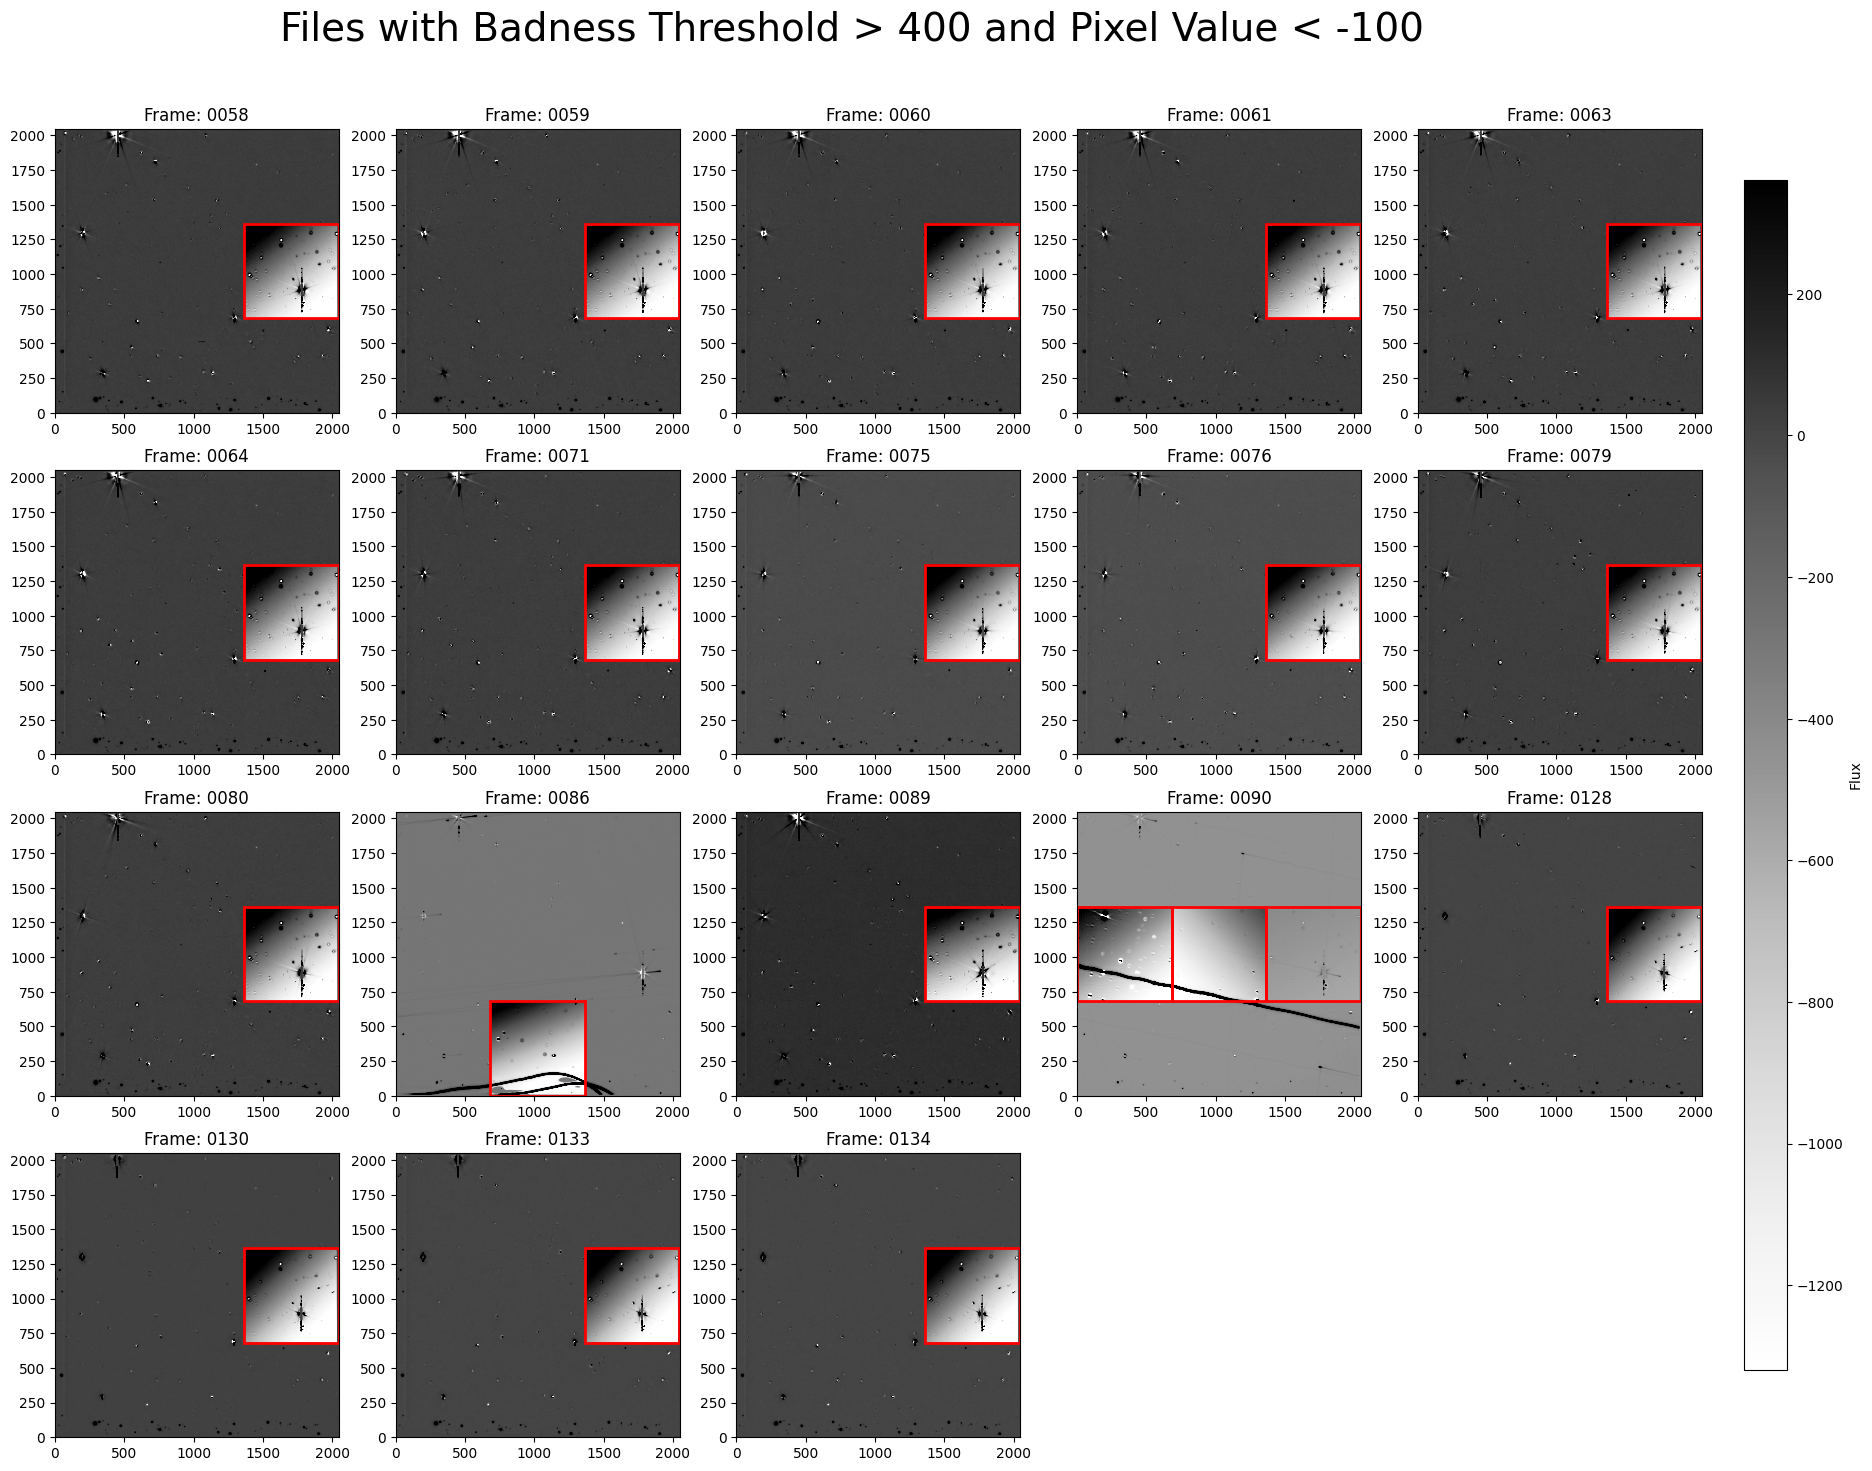

In [92]:
p = "/home/mwalker/git/Didymos_data/subtraction_analysis/examined_subtractions_table_2026-07-12.ecsv"
t = bad_filenames_500
b = "/home/mwalker/git/Didymos_data/f06_012_e93"
bad_t_filt = bad_sub_highlighter(p,b)


In [38]:
print(bad_t_filt["mean"][17:24])

       mean       
------------------
-555.8209838867188
 -515.554931640625
-527.7075805664062


/tmp/ipykernel_7217/3781801356.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


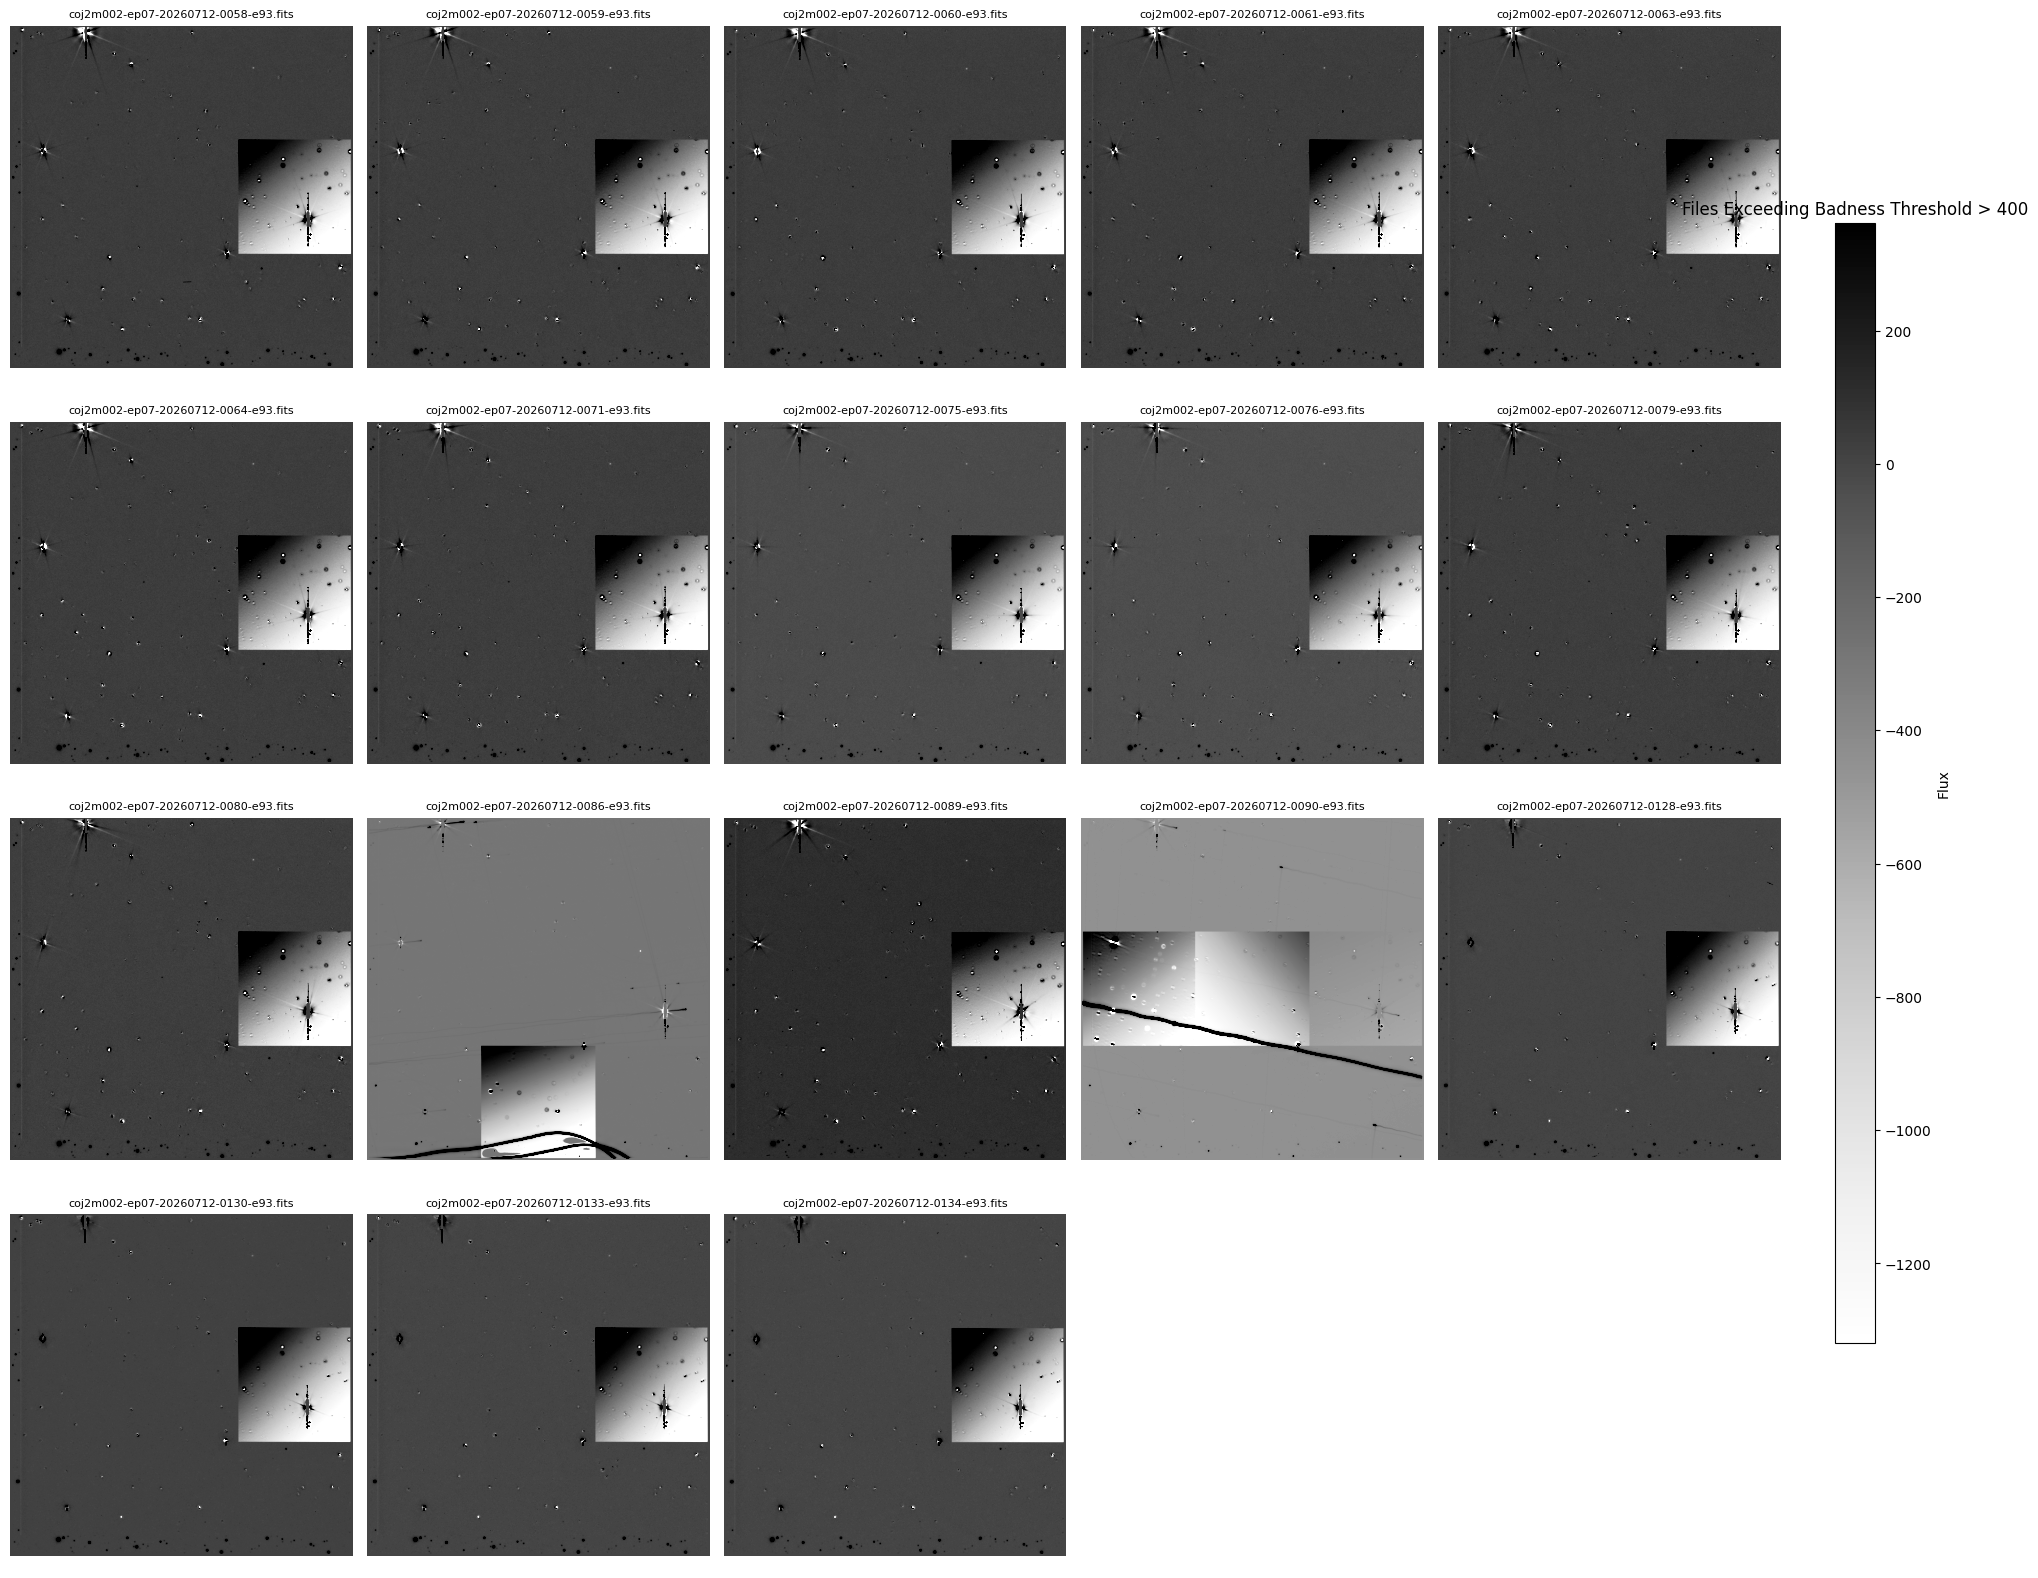

In [50]:
# list of bad subtraction FITS files

files = [os.path.join("/home/mwalker/git/Didymos_data/f06_012_e93",f) for f in bad_filenames_500]

n = len(files)

# make roughly square grid
ncols = math.ceil(np.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4*ncols, 4*nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, filename in zip(axes, files):

    with fits.open(filename) as hdul:
        data = hdul[0].data

    # optional: improve contrast
    vmin, vmax = np.nanpercentile(data, [1, 99])

    im = ax.imshow(
        data,
        origin="lower",
        cmap="Greys",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(filename.split("/")[-1], fontsize=8)
    ax.axis("off")

# remove unused panels
for ax in axes[len(files):]:
    ax.axis("off")

# colorbar on far right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

fig.colorbar(
    im,
    cax=cbar_ax,
    label="Flux"
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.title("Files Exceeding Badness Threshold > 400")
plt.show()